In [29]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample
import random

import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA = Path('..') / 'data'
LOANS_INCOME_CSV = DATA / 'loans_income.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'
WEB_PAGE_DATA_CSV = DATA / 'web_page_data.csv'
FOUR_SESSIONS_CSV = DATA / 'four_sessions.csv'
CLICK_RATE_CSV = DATA / 'click_rates.csv'
IMANISHI_CSV = DATA / 'imanishi_data.csv'

In [3]:
loans = pd.read_csv(LOANS_INCOME_CSV)
loans.head()

,x
0,67000
1,52000
2,100000
3,78762
4,37041


In [4]:
loans.sample(1000).mean()

x    67626.086
dtype: float64

In [5]:
sample_data = pd.DataFrame({
    'income': loans.sample(1000).x,
    'type': 'Data',
})

mean_5 = pd.DataFrame({
    'income': [loans.sample(5).x.mean() for _ in range(1000)],
    'type': 'mean 5'
})

mean_20 = pd.DataFrame({
    'income': [loans.sample(20).x.mean() for _ in range(1000)],
    'type': 'mean 20'
})

results = pd.concat([sample_data, mean_5, mean_20])


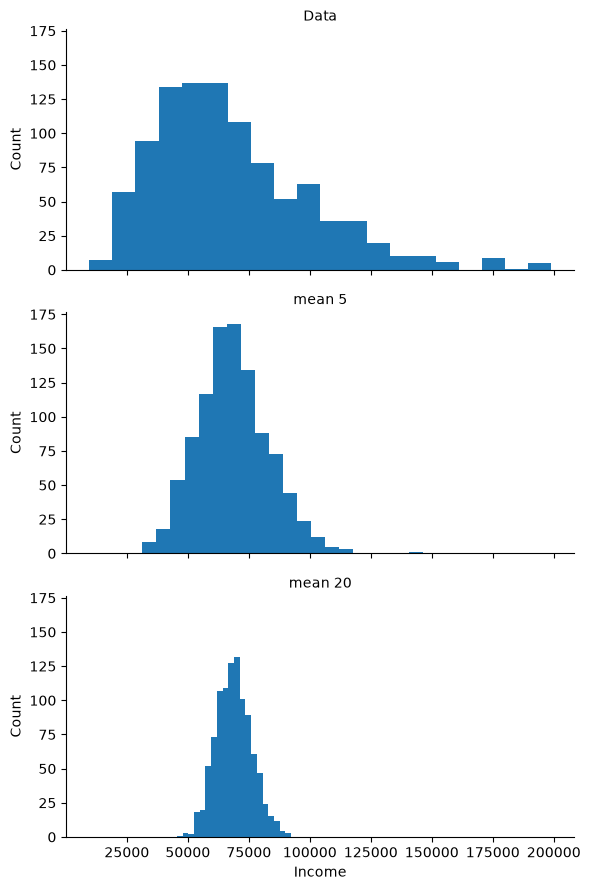

In [6]:

g = sns.FacetGrid(results, col='type', col_wrap=1, 
                  height=3, aspect=2)
g.map(plt.hist, 'income', bins=20)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')

plt.tight_layout()
plt.show()

* Algoritmo Boostrap

In [7]:
loans.mean()

x    68760.51844
dtype: float64

68762.29096966
x    68760.51844
dtype: float64


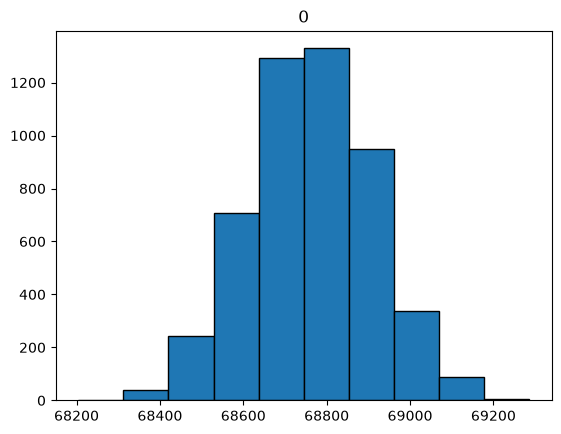

In [8]:
n = len(loans)
R = 5000

means = [loans.sample(n, replace=True).x.mean() for _ in range(R)]

print(pd.Series(means).mean())
print(loans.mean())

pd.DataFrame(means).hist(grid=False, edgecolor='black')

plt.show()

55734.1


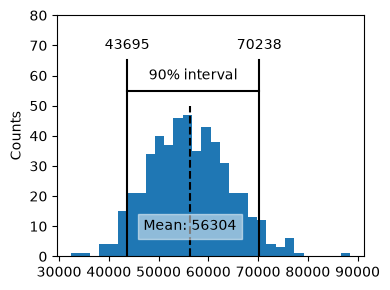

In [73]:

sample20 = loans.x.sample(20, replace=False, random_state=3)
print(sample20.mean())
results = [sample20.sample(20, replace=True).mean() for _ in range(500)]
#for nrepeat in range(500):
#    sample = resample(sample20)
#    results.append(sample.mean())



results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [55, 55], color='black')
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color='black')
    ax.text(x, 70, f'{x:.0f}', 
            horizontalalignment='center', verticalalignment='center')
ax.text(sum(confidence_interval) / 2, 60, '90% interval',
        horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 10, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

In [17]:
web_data = pd.read_csv(WEB_PAGE_DATA_CSV)

web_data.Time = web_data.Time * 100
web_data.head()

,Page,Time
0,Page A,21.0
1,Page B,253.0
2,Page A,35.0
3,Page B,71.0
4,Page A,67.0


In [18]:
nA = web_data[web_data['Page'] == 'Page A'].shape[0]
nB = web_data[web_data['Page'] == 'Page B'].shape[0]

print(f'Page A: {nA} visits')
print(f'Page B: {nB} visits')

Page A: 21 visits
Page B: 15 visits


In [23]:
meanA = web_data[web_data['Page'] == 'Page A']['Time'].mean()
meanB = web_data[web_data['Page'] == 'Page B']['Time'].mean()

print(f'Page A: {meanA:.2f} seconds')
print(f'Page B: {meanB:.2f} seconds')
print(f'Difference: {meanB - meanA:.3f} seconds')

Page A: 126.33 seconds
Page B: 162.00 seconds
Difference: 35.667 seconds


In [56]:
diff_times = meanB - meanA

In [22]:
medianA = web_data[web_data['Page'] == 'Page A'].Time.median()
medianB = web_data[web_data['Page'] == 'Page B'].Time.median()

print(f'Page A: {medianA:.2f} seconds')
print(f'Page B: {medianB:.2f} seconds')

Page A: 95.00 seconds
Page B: 147.00 seconds


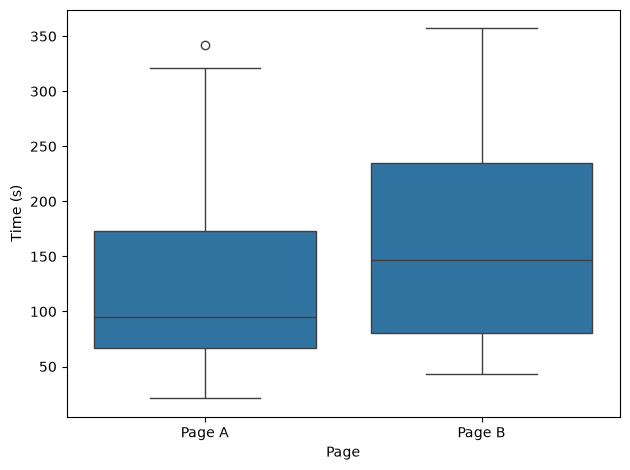

In [20]:
ax = sns.boxplot(data=web_data, x='Page', y='Time')
ax.set_ylabel('Time (s)')
plt.tight_layout()
plt.show()

* La pregunta es si la diferencia de medias que hay en A y B puede deberse unicamente a factores aleatorios o realmente son diferentes.
* Seguimos con un **Pemutation Test** para ver esto. 

In [24]:
nA, nB

(21, 15)

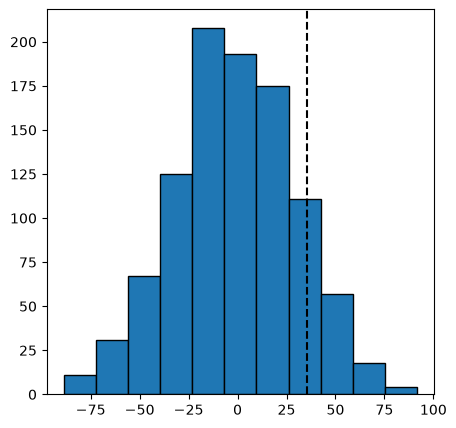

In [71]:
means = []
for _ in range(1000):
    group_A = web_data.sample(nA, replace=False)
    group_B = web_data.iloc[~web_data.index.isin(group_A.index)]

    mean_A = group_A['Time'].mean()
    mean_B = group_B['Time'].mean()

    means.append(mean_B - mean_A)

means = pd.Series(means)

fig, ax = plt.subplots(figsize=(5, 5))

means.hist(grid=False, edgecolor='black', bins=11, ax=ax)
ax.axvline(35.667, color='black', linestyle='--')

plt.show()


* Del grafico podemos ver que no parece un valor muy alejado de la media, con lo cual no descartamos que la diferencia que vemos sea por efectos aleatorios (No descartamos la hipotesis nula).
* Que tan probable es que los tiempos de diferencia excedan lo que vimos?

In [72]:
p = (means > diff_times).mean()
print(f'{p*100:.2f}%')

12.20%


* Veamos el concepto de **p-value** usando otro dataset.
* Queremos hacer el mismo permutation test que antes 

In [77]:
AB = pd.DataFrame({
    'Price A': [200, 23539],
    'Price B': [182, 22406]
}, index=['Conversion', 'No Conversion'])
AB.head()

,Price A,Price B
Conversion,200,182
No Conversion,23539,22406


In [88]:
pA = AB['Price A'].values[0] / (AB['Price A'].sum())
pB = AB['Price B'].values[0] / (AB['Price B'].sum())

print(round(pA - pB,6)*100)

0.0368


In [ ]:
conversion = [1] * 382
conversion.extend([0] * (23539 + 22406))
conversion = pd.Series(conversion)

15536    0
30320    0
20006    0
42830    0
3996     0
9584     0
43933    0
2896     0
1241     0
44763    0
dtype: int64

In [104]:
random.seed(1)

def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()
    
means_conv = [perm_fun(conversion, AB['Price A'].sum(), AB['Price B'].sum())*100 for _ in range(1000)]

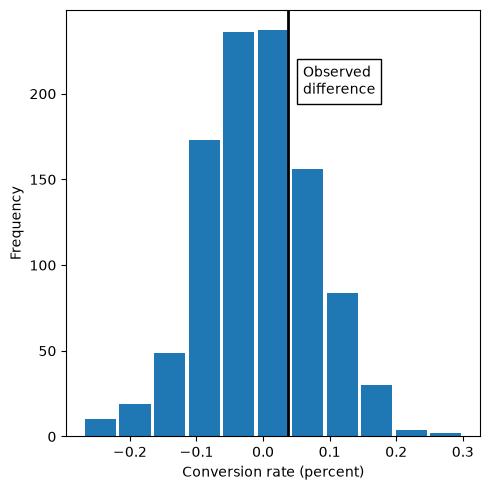

In [107]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(means_conv, bins=11, rwidth=0.9)
ax.axvline(x=(pA-pB)*100, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

* Este es el p-value

In [110]:
print(f'{(means_conv > (pA-pB)*100).mean()*100}%')

30.4%


In [111]:
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)

print(f'p-value for single sided test: {p_value / 2:.4f}')

p-value for single sided test: 0.3498


# ANOVA

In [3]:
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)
four_sessions.head()

,Page,Time
0,Page 1,164
1,Page 2,178
2,Page 3,175
3,Page 4,155
4,Page 1,172


In [4]:
four_sessions.shape

(20, 2)

In [5]:
four_sessions['idx'] = four_sessions.groupby('Page').cumcount()
four_sessions.pivot(index='idx', columns='Page', values='Time')


Page,Page 1,Page 2,Page 3,Page 4
idx,,,,
0,164,178,175,155
1,172,191,193,166
2,177,182,171,164
3,156,185,163,170
4,195,177,176,168


In [6]:
sessions_pivot = four_sessions.pivot_table(index='idx', columns='Page', values='Time')
sessions_pivot

Page,Page 1,Page 2,Page 3,Page 4
idx,,,,
0,164.0,178.0,175.0,155.0
1,172.0,191.0,193.0,166.0
2,177.0,182.0,171.0,164.0
3,156.0,185.0,163.0,170.0
4,195.0,177.0,176.0,168.0


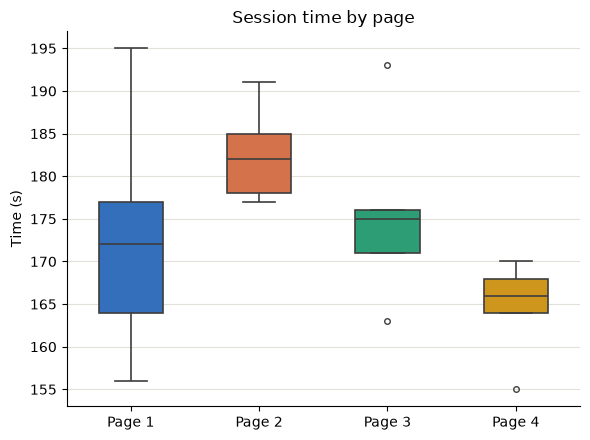

In [23]:
palette = ["#1c6dd1", '#eb6834', '#1baf7a', '#eda100']

fig, ax = plt.subplots(figsize=(6, 4.5))

sns.boxplot(
    data=sessions_pivot,
    palette=palette,
    width=0.5,
    linewidth=1.2,
    fliersize=4,
    ax=ax,
)

ax.set_xlabel('')
ax.set_ylabel('Time (s)')
ax.set_title('Session time by page')

sns.despine(ax=ax)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [7]:
std_obs = sessions_pivot.mean().std()
std_obs

np.float64(7.444908774905617)

In [24]:
def ANOVA(x):    
    
    shuffled = np.random.permutation(x.values.flatten())

    resampled = pd.DataFrame(
        shuffled.reshape(x.shape),
        columns=x.columns
    )

    return resampled.mean().std()

In [25]:
std_sim = pd.Series([ANOVA(sessions_pivot) for _ in range(3000)])
std_sim

0       2.277425
1       5.175584
2       3.883298
3       5.034547
4       5.412332
          ...   
2995    6.654322
2996    2.660827
2997    3.172801
2998    2.802380
2999    6.217180
Length: 3000, dtype: float64

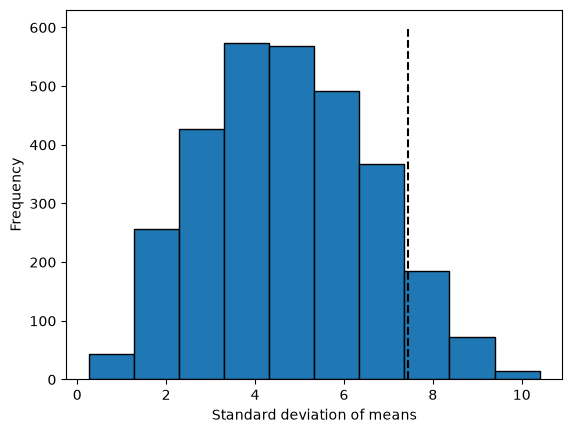

In [28]:
std_sim.hist(edgecolor='black', grid=False)

plt.vlines(x=std_obs, ymin=0, ymax=600, color='black', linestyle='--')

plt.xlabel('Standard deviation of means')
plt.ylabel('Frequency')

plt.show()

* A simple vista parece que cae en las regiones de la cola mas exterior. Puede ser que realmente sean diferentes las paginas. Calculo el p-value

In [27]:
p_value_ANOVA = (std_sim > std_obs).mean()
print(f'p-value for ANOVA test: {p_value_ANOVA:.4f}')

p-value for ANOVA test: 0.0843


* Si estamos en un modelo de azar, el 8.4% de las veces los valores de std_sim son iguales o mas extremos que el valor observado. Con lo cual si usamos un alpha=0.05, no podemos descartar la hipotesis nula, ya que p-value > alpha

In [31]:
model = smf.ols('Time ~ Page', data=four_sessions).fit()
aov_table = sm.stats.anova_lm(model)
aov_table

,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


# Chi square

## Chi square Resampling Aproach

In [34]:
click_rates = pd.read_csv(CLICK_RATE_CSV)
click_rates.head()

,Headline,Click,Rate
0,Headline A,Click,14
1,Headline A,No-click,986
2,Headline B,Click,8
3,Headline B,No-click,992
4,Headline C,Click,12


In [35]:
click_rates.pivot(index='Click', columns='Headline', values='Rate')

Headline,Headline A,Headline B,Headline C
Click,,,
Click,14,8,12
No-click,986,992,988


In [44]:
click_rates_pivot = click_rates.pivot(index='Click', columns='Headline', values='Rate')

In [57]:
clicks = [1] * click_rates_pivot.loc['Click'].sum()
clicks = clicks + [0] * click_rates_pivot.loc['No-click'].sum()
len(clicks)

3000

In [78]:
def chi_square_test(x, expected):
    clicks_shuffled = np.random.permutation(x)

    new_clicks = pd.DataFrame({
        'Headline A': clicks_shuffled[:1000],
        'Headline B': clicks_shuffled[1000:2000],
        'Headline C': clicks_shuffled[2000:3000],
    }).map(lambda x: 'No-click' if x == 0 else 'Click').apply(pd.Series.value_counts).reindex(['Click', 'No-click'])

    return (new_clicks - expected)**2/expected

In [79]:
expected_clicks = round(click_rates_pivot.loc['Click'].sum()/3, 2)
expected_no_clicks = round(click_rates_pivot.loc['No-click'].sum()/3, 2)

expected_df = pd.DataFrame({
    'Headline A': [expected_clicks, expected_no_clicks],
    'Headline B': [expected_clicks, expected_no_clicks],
    'Headline C': [expected_clicks, expected_no_clicks]
}, index=['Click', 'No-click'])

expected_df

,Headline A,Headline B,Headline C
Click,11.33,11.33,11.33
No-click,988.67,988.67,988.67


* Estos son todos los chi2 simulados

In [91]:
chi_square_sim_list = pd.Series([chi_square_test(clicks, expected_df).sum().sum() for _ in range(3000)])

* Este es el chi2 observado

In [95]:
def chi2_observed(df):
    return ((df - expected_df)**2/expected_df).sum().sum()

chi_square_observed = chi2_observed(click_rates_pivot)
print(f'Chi-square observed: {chi_square_observed:.2f}')

Chi-square observed: 1.67


In [93]:
(chi_square_sim_list > chi_square_observed).mean()

np.float64(0.429)

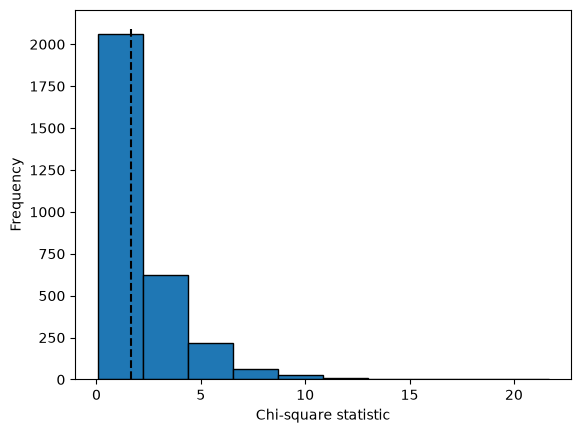

In [98]:
chi_square_sim_list.hist(edgecolor='black', grid=False)

plt.vlines(x=chi_square_observed, ymin=0, ymax=2100, color='black', linestyle='--')

plt.xlabel('Chi-square statistic')
plt.ylabel('Frequency')

plt.show()

* Suponiendo que no hay diferencia entre las paginas la diferencia observado en los clicks es muy frecuente, con lo cual no descartamos la hipotesis nula.